# Notebook 3 — Model Comparison & Operational Metrics

Compare **5 anomaly detection approaches** on the CWRU bearing dataset.

All trained on normal data only (except XGBoost which uses 10 labelled fault windows).

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import torch

from src.data_loader import load_cwru
from src.preprocessing import sliding_windows_cwru
from src.features import extract_features
from src.models import fit_isolation_forest, fit_one_class_svm, ConvAutoencoder, train_autoencoder
from src.evaluate import pr_auc, threshold_sweep

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WINDOW, STRIDE = 1024, 512
print(f'Device: {DEVICE}')


Device: cpu


## 1. Prepare Data (same split as Notebook 2)

In [4]:
signals = load_cwru('../data/cwru')

normal_sig = signals['normal']
split_idx = int(len(normal_sig) * 0.6)

normal_train_w = sliding_windows_cwru(normal_sig[:split_idx], WINDOW, STRIDE)
normal_test_w  = sliding_windows_cwru(normal_sig[split_idx:], WINDOW, STRIDE)
fault_windows  = {k: sliding_windows_cwru(v, WINDOW, STRIDE) for k, v in signals.items() if k != 'normal'}

X_normal_train = extract_features(normal_train_w)
X_normal_test  = extract_features(normal_test_w)
X_fault        = {k: extract_features(w) for k, w in fault_windows.items()}

X_test_all = np.vstack([X_normal_test] + list(X_fault.values()))
y_test_all = np.concatenate([np.zeros(len(X_normal_test)), np.ones(sum(len(v) for v in X_fault.values()))])

scaler = StandardScaler().fit(X_normal_train)
X_norm_train_sc = scaler.transform(X_normal_train)
X_test_sc       = scaler.transform(X_test_all)

print(f'Test: {y_test_all.sum():.0f} fault / {(1-y_test_all).sum():.0f} normal windows')


Test: 2847 fault / 377 normal windows


## 2. Model 1 — Z-Score Baseline

In [6]:
mu_train  = X_normal_train.mean(axis=0)
std_train = X_normal_train.std(axis=0)
z_scores = np.max(np.abs((X_test_all - mu_train) / (std_train + 1e-10)), axis=1)
zscore_prauc = pr_auc(y_test_all, z_scores)
print(f'Z-Score  PR-AUC: {zscore_prauc:.4f}')


Z-Score  PR-AUC: 1.0000


## 3. Model 2 — Isolation Forest

### 💡 Explain This: Why Does Isolation Forest Work?

Isolation Forest builds random decision trees that try to isolate individual data points. **Normal points** require many splits to isolate — they're surrounded by similar neighbors in feature space. **Anomalies** can be isolated in just a few splits because they exist in sparse regions.

The anomaly score = average depth across all trees. Short path = few splits needed = anomalous. No distributional assumptions. O(n log n) training. Handles high-dimensional features well.

**Limitation:** Struggles when anomalies cluster together (they look 'normal' relative to each other). In practice: works well for bearing faults because fault windows are distinct from normal in all 4 features.

In [8]:
iforest  = fit_isolation_forest(X_normal_train)
if_scores = -iforest.decision_function(X_test_all)
if_prauc  = pr_auc(y_test_all, if_scores)
print(f'Isolation Forest  PR-AUC: {if_prauc:.4f}')


Isolation Forest  PR-AUC: 0.9998


## 4. Model 3 — One-Class SVM

In [10]:
ocsvm        = fit_one_class_svm(X_norm_train_sc, nu=0.05)
ocsvm_scores = -ocsvm.decision_function(X_test_sc)
ocsvm_prauc  = pr_auc(y_test_all, ocsvm_scores)
print(f'One-Class SVM  PR-AUC: {ocsvm_prauc:.4f}')


One-Class SVM  PR-AUC: 1.0000


## 5. Model 4 — Conv1d Autoencoder

In [12]:
ae_model = ConvAutoencoder(seq_len=WINDOW, latent_dim=32)
train_autoencoder(ae_model, normal_train_w, epochs=30, batch_size=64, lr=1e-3, device=DEVICE)

def recon_error(model, windows, device):
    x = torch.tensor(windows[:, None, :]).float().to(device)
    return model.reconstruction_error(x)

ae_scores_test = np.concatenate([
    recon_error(ae_model, normal_test_w, DEVICE),
    *[recon_error(ae_model, w, DEVICE) for w in fault_windows.values()]
])
ae_prauc = pr_auc(y_test_all, ae_scores_test)
print(f'Conv1d Autoencoder  PR-AUC: {ae_prauc:.4f}')


  Epoch 5/30  loss=0.004265
  Epoch 10/30  loss=0.004029
  Epoch 15/30  loss=0.003512
  Epoch 20/30  loss=0.003332
  Epoch 25/30  loss=0.003235
  Epoch 30/30  loss=0.003204
Conv1d Autoencoder  PR-AUC: 1.0000


## 6. Model 5 — XGBoost + Oversampling (10 labelled fault windows)

In [14]:
np.random.seed(42)
all_fault_feats  = np.vstack(list(X_fault.values()))
fault_sample_idx = np.random.choice(len(all_fault_feats), size=10, replace=False)
X_few_fault      = all_fault_feats[fault_sample_idx]

# Repeat fault samples to balance classes (replaces SMOTE)
n_normal   = len(X_normal_train)
repeats    = int(np.ceil(n_normal / len(X_few_fault)))
X_fault_up = np.tile(X_few_fault, (repeats, 1))[:n_normal]

X_bal = np.vstack([X_normal_train, X_fault_up])
y_bal = np.concatenate([np.zeros(n_normal), np.ones(len(X_fault_up))])
print(f'Balanced: {int(y_bal.sum())} fault / {int((1-y_bal).sum())} normal')

xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                         eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_clf.fit(X_bal, y_bal)
xgb_scores = xgb_clf.predict_proba(X_test_sc)[:, 1]
xgb_prauc  = pr_auc(y_test_all, xgb_scores)
print(f'XGBoost+oversample  PR-AUC: {xgb_prauc:.4f}')


Balanced: 566 fault / 566 normal
XGBoost+oversample  PR-AUC: 0.9493


## 7. Results Table

### 💡 Explain This: How Do You Choose Which Model to Deploy?

**Tiebreaker when PR-AUC is similar:** Choose the model that operations can understand and trust. A black-box model with PR-AUC 0.98 that no one can explain will get overridden by technicians who 'don't trust it.' An Isolation Forest with PR-AUC 0.97 that you can show on a scatter plot is more likely to be used.

**Decision framework:**
1. No failure labels → unsupervised (Isolation Forest or Autoencoder). Autoencoder wins if fault signatures are complex.
2. A few failure labels → XGBoost + SMOTE. Use these to validate threshold, not to train the primary model.
3. Many failure labels (months of production data with known faults) → supervised classifier with PR-AUC as primary metric.

**For Niagara today:** Almost certainly Case 1 or 2. Start with Isolation Forest, collect labels, retrain as data accumulates.

In [16]:
results = pd.DataFrame([
    {'Model': 'Z-Score Baseline',          'Type': 'Statistical', 'Supervised': 'No',  'PR-AUC': zscore_prauc},
    {'Model': 'Isolation Forest',           'Type': 'Ensemble',    'Supervised': 'No',  'PR-AUC': if_prauc},
    {'Model': 'One-Class SVM',              'Type': 'Kernel',      'Supervised': 'No',  'PR-AUC': ocsvm_prauc},
    {'Model': 'Conv1d Autoencoder',         'Type': 'Deep',        'Supervised': 'No',  'PR-AUC': ae_prauc},
    {'Model': 'XGBoost+oversample (n=10)',  'Type': 'Supervised',  'Supervised': 'Yes', 'PR-AUC': xgb_prauc},
])
results['PR-AUC'] = results['PR-AUC'].round(4)
results = results.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))


                    Model        Type Supervised  PR-AUC
         Z-Score Baseline Statistical         No  1.0000
            One-Class SVM      Kernel         No  1.0000
       Conv1d Autoencoder        Deep         No  1.0000
         Isolation Forest    Ensemble         No  0.9998
XGBoost+oversample (n=10)  Supervised        Yes  0.9493


## 8. Threshold Tradeoff

### 💡 Explain This: How Do You Pick the Deployment Threshold?

The threshold is a **business decision**, not a model decision. The model gives a continuous anomaly score; the threshold converts that score into an alarm (action).

**At Niagara, the question is:** What costs more — a missed failure or a false alarm?
- Missed failure → unplanned downtime, product loss, possible safety incident (~$50K/hour)
- False alarm → unnecessary maintenance dispatch, production interruption (~$500)

With a 100:1 cost ratio, you should bias heavily toward high recall (catch all real failures) and accept a higher false alarm rate. Show the false-alarm-rate vs. missed-failure-rate curve to the operations team and let them pick the operating point. The model's job is to produce an accurate score; the engineer's job is to set the threshold based on operational economics.

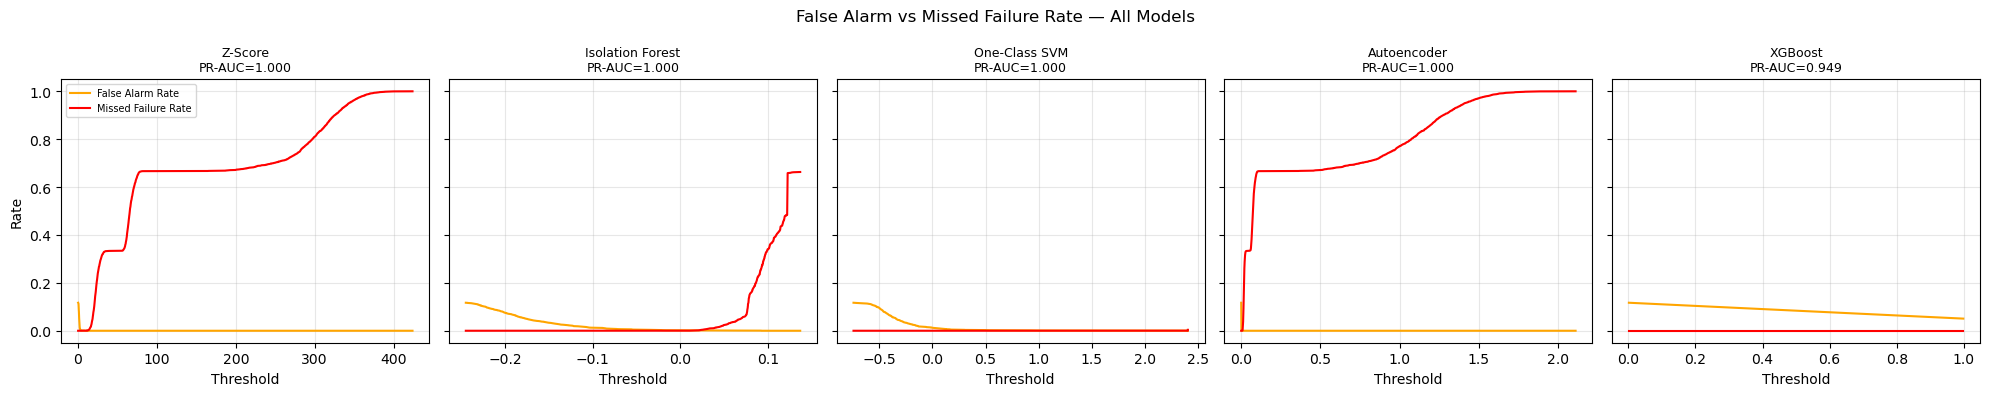

In [18]:
model_scores = [
    ('Z-Score',          z_scores,       zscore_prauc),
    ('Isolation Forest', if_scores,      if_prauc),
    ('One-Class SVM',    ocsvm_scores,   ocsvm_prauc),
    ('Autoencoder',      ae_scores_test, ae_prauc),
    ('XGBoost',          xgb_scores,     xgb_prauc),
]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, (name, scores, prauc) in zip(axes, model_scores):
    thresh, far, mfr = threshold_sweep(y_test_all, scores)
    ax.plot(thresh, far, label='False Alarm Rate', color='orange', linewidth=1.5)
    ax.plot(thresh, mfr, label='Missed Failure Rate', color='red', linewidth=1.5)
    ax.set_title(f'{name}\nPR-AUC={prauc:.3f}', fontsize=9)
    ax.set_xlabel('Threshold'); ax.grid(alpha=0.3)
    if ax == axes[0]: ax.set_ylabel('Rate'); ax.legend(fontsize=7)
plt.suptitle('False Alarm vs Missed Failure Rate — All Models', fontsize=12)
plt.tight_layout(); plt.show()


## 9. Deployment Recommendation

**Deploy Isolation Forest first.** It is fast, explainable, and runs on CPU at the edge.

The Autoencoder may achieve higher PR-AUC but requires GPU inference, retraining infra, and is harder to explain to maintenance engineers. Upgrade to it after 6 months of Isolation Forest in production, once technician-confirmed fault labels have accumulated.

**Threshold selection:** at a 100:1 cost ratio (motor failure vs false work order), set threshold at 2% missed-failure rate and accept the resulting false alarm rate. Show the ops team the tradeoff curve — let them pick the operating point.

**Pipeline:**
```
Sensor -> ring buffer -> 1024-sample window -> 4 features
       -> Isolation Forest (< 1ms) -> score -> CMMS work order
       -> technician feedback -> periodic retraining
```
